In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

In [6]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

Génération des données synthétiques

In [7]:
def generate_custom_data(shift=2.0, n_samples=500, spread=0.5, seed=42):
    np.random.seed(seed)
    n_cluster = n_samples // 2

    # Cluster 1
    x1 = np.random.normal(2, spread, n_cluster)
    y1 = np.random.normal(2, spread, n_cluster)

    # Cluster 2
    x2 = np.random.normal(2 + shift, spread, n_cluster)
    y2 = np.random.normal(2 + shift, spread, n_cluster)

    X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
    y = np.array([0]*n_cluster + [1]*n_cluster)

    return X, y

Visualisation des données

In [8]:
def plot_data(X, y, title=""):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='blue', label='Classe 0')
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='red', label='Classe 1')
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

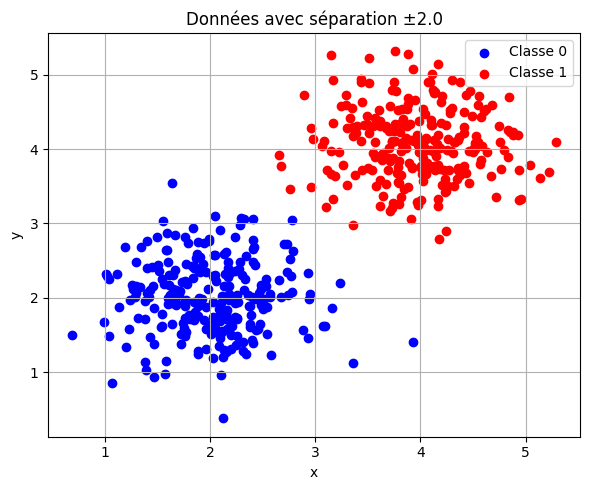

In [9]:
X, y = generate_custom_data(shift=2.0)
plot_data(X, y, title="Données avec séparation ±2.0")

Frontière de décision

In [10]:
def plot_decision_boundary(model, X, y, title=""):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#AAAAFF', '#FFAAAA'])
    cmap_bold = ListedColormap(['#0000FF', '#FF0000'])

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k')
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

Modèle Sigmoid + ReLU

In [11]:
def run_logistic_models(X, y, activation_fn=None, label=""):
    if activation_fn:
        transformer = FunctionTransformer(activation_fn)
        X_trans = transformer.fit_transform(X)
    else:
        X_trans = X

    X_train, X_test, y_train, y_test = train_test_split(X_trans, y, test_size=0.3, random_state=0)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    plot_decision_boundary(model, X_trans, y, f"{label} - Acc: {acc:.2f}")
    return acc

Cas de Shift ±2.0

=== Shift ±2.0 ===


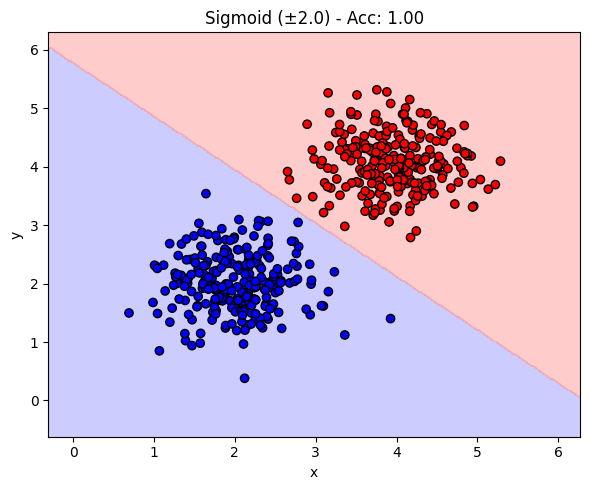

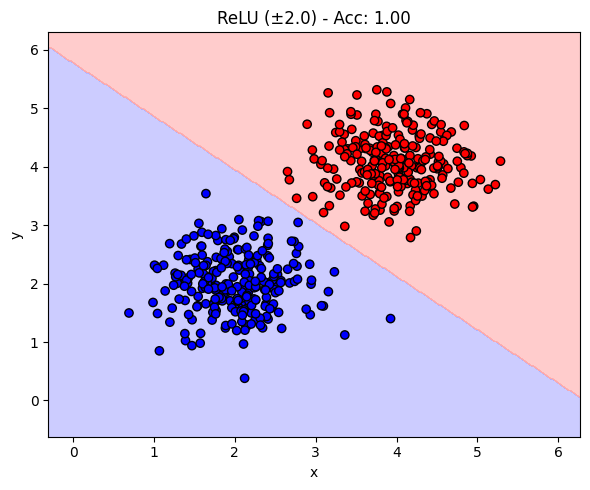

In [12]:
X2, y2 = generate_custom_data(shift=2.0)
print("=== Shift ±2.0 ===")
acc_s2 = run_logistic_models(X2, y2, None, "Sigmoid (±2.0)")
acc_r2 = run_logistic_models(X2, y2, relu, "ReLU (±2.0)")

Cas de Shift ±0.01

=== Shift ±0.01 ===


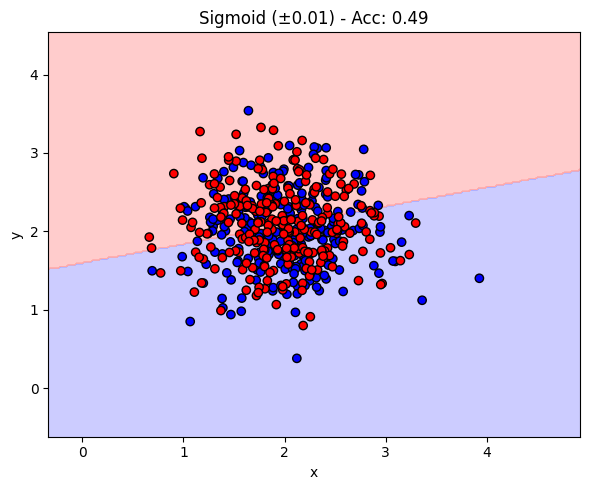

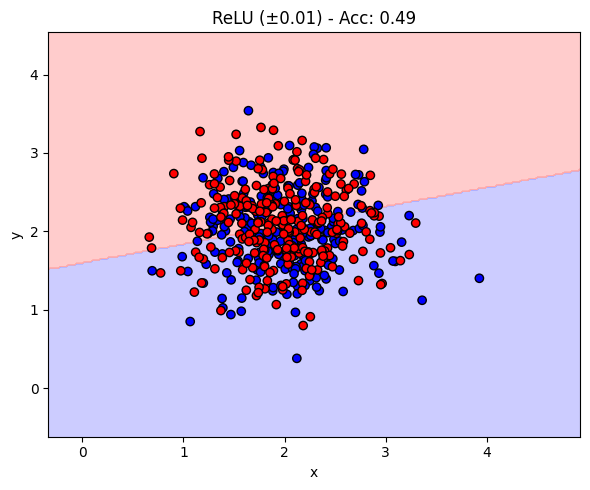

In [13]:
X01, y01 = generate_custom_data(shift=0.01)
print("=== Shift ±0.01 ===")
acc_s01 = run_logistic_models(X01, y01, None, "Sigmoid (±0.01)")
acc_r01 = run_logistic_models(X01, y01, relu, "ReLU (±0.01)")

Moons Dataset

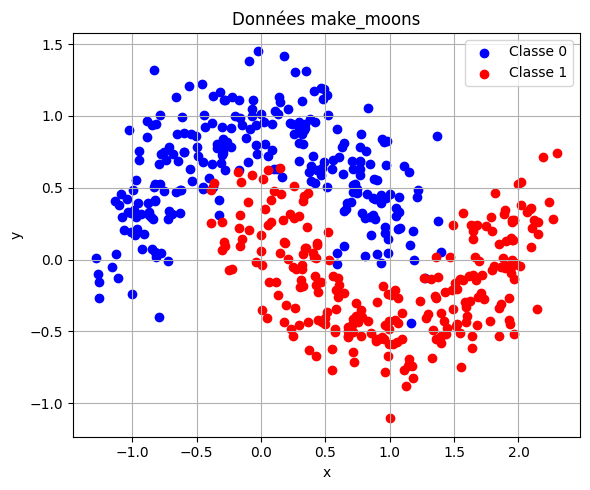

In [14]:
from sklearn.datasets import make_moons

# Cellule 11 - Génération des données
X_moon, y_moon = make_moons(n_samples=500, noise=0.2, random_state=0)
plot_data(X_moon, y_moon, title="Données make_moons")

=== Données make_moons ===


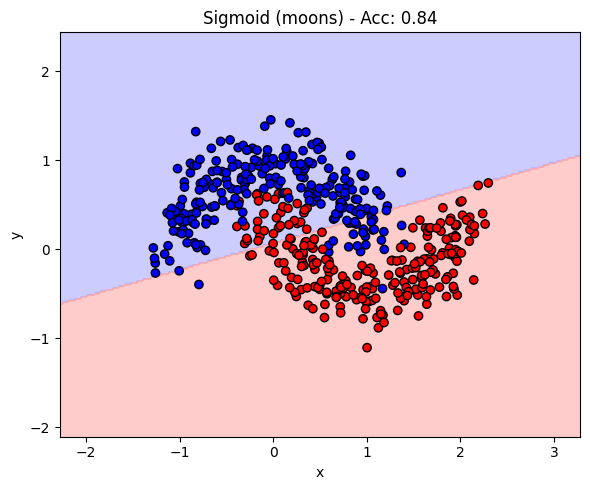

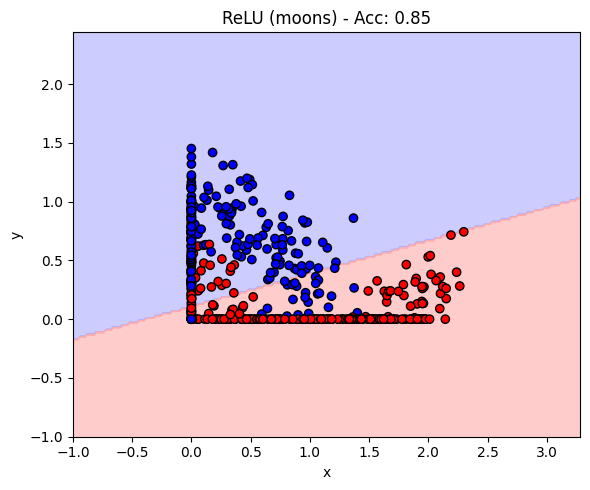

In [15]:
print("=== Données make_moons ===")
acc_s_moon = run_logistic_models(X_moon, y_moon, None, "Sigmoid (moons)")
acc_r_moon = run_logistic_models(X_moon, y_moon, relu, "ReLU (moons)")